In [19]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------
env = gym.make("FrozenLake-v1", desc = ["FFFHF", "FFSFF", "FFHFH", "FFFGF", "FHFFH"], is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n



In [21]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1          
gamma = 0.99         # Discount factor 

epsilon = 1.0        # Initial exploration rate
epsilon_min = 0.05
epsilon_decay = 0.9995

In [22]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))
episode_rewards = []

# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    else:
        return np.argmax(Q[state])

In [23]:
#-------------------------------------------------
# Q-Learning Training
# -------------------------------------------------

for episode in range(num_episodes):

    state, info = env.reset()
    total_reward = 0

    for step in range(max_steps_per_episode):

        # Choose action using epsilon-greedy
        action = epsilon_greedy_action(state, epsilon)

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Q-Learning update
        # Q(s,a) <- Q(s,a) + alpha [r + gamma * max Q(s',a') - Q(s,a)]
        if terminated or truncated:
            target = reward
        else:
            target = reward + gamma * np.max(Q[next_state])

        Q[state, action] += alpha * (
            target - Q[state, action]
        )

        # Move to next state
        state = next_state
        total_reward += reward

        # Stop episode if terminated
        if terminated or truncated:
            break

    # Store total reward
    episode_rewards.append(total_reward)

    # Decay epsilon
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )


# -------------------------------------------------
# Extract State-Value Function and Policy
# -------------------------------------------------

# V(s) = max_a Q(s,a)
state_values = np.max(Q, axis=1)

# π(s) = argmax_a Q(s,a)
learned_policy = np.argmax(Q, axis=1)




In [24]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(5, 5), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(5, 5)

    print("\nLearned Policy:")
    print(policy_grid)


In [25]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.912 0.903 0.951 0.863]
 [0.938 0.959 0.961 0.95 ]
 [0.951 0.97  0.97  0.961]
 [0.961 0.98  0.961 0.97 ]
 [0.97  0.968 0.96  0.959]
 [0.936 0.866 0.961 0.93 ]
 [0.951 0.95  0.97  0.951]
 [0.961 0.    0.98  0.961]
 [0.97  0.99  0.97  0.97 ]
 [0.98  0.    0.97  0.961]
 [0.721 0.531 0.786 0.942]
 [0.791 0.316 0.    0.96 ]
 [0.    0.    0.    0.   ]
 [0.    1.    0.    0.98 ]
 [0.    0.    0.    0.   ]
 [0.3   0.101 0.208 0.815]
 [0.536 0.    0.155 0.457]
 [0.059 0.    0.41  0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.028 0.031 0.    0.347]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.951 0.961 0.97  0.98  0.97 ]
 [0.961 0.97  0.98  0.99  0.98 ]
 [0.942 0.96  0.    1.    0.   ]
 [0.815 0.536 0.41  0.    0.   ]
 [0.347 0.    0.    0.    0.   ]]

Learned Policy:
[['R' 'R' 'D' 'D' 'L']
 ['R' 'R' 'R' 'D' 'L']
 ['U' 'U' 'L' 'D' 'L']
 ['U' 'L' 'R' 'L' 'L']


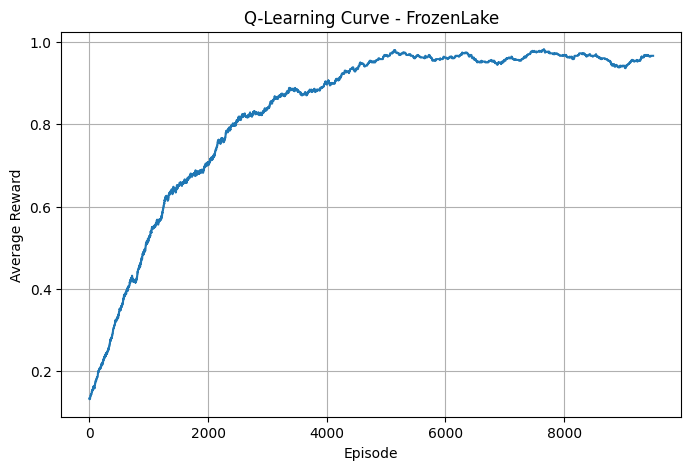

In [26]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()